# SAE Training on Federated Learning Checkpoints

In [1]:
# Cell 1: Environment Bootstrap
import os
REPO_URL = "https://github.com/ha405/FedMI.git"
BRANCH = "cvpr"

if not os.path.exists("FedMI"):
    get_ipython().system(f"git clone -b {BRANCH} {REPO_URL}")
else:
    # Update repo if already exists to get latest fixes
    get_ipython().system(f"cd FedMI && git pull origin {BRANCH}")

os.chdir("FedMI")

from fedmi.env import setup, CHECKPOINT_DIR, DATA_DIR
setup()

# Install dependencies required by the original notebook
%pip install -q einops opencv-python scikit-image overcomplete

From https://github.com/ha405/FedMI
 * branch            cvpr       -> FETCH_HEAD
Already up to date.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
# sys.path.append('..') # Original path, now unnecessary as we are in the repo root

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

class SimpleCNN(nn.Module):
    def __init__(self, conv_channels: List[int] = None, num_classes: int = 10, input_channels: int = 1):
        super(SimpleCNN, self).__init__()
        if conv_channels is None:
            conv_channels = [32, 64, 128]
        
        self.conv1 = nn.Conv2d(input_channels, conv_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(conv_channels[0], conv_channels[1], 3, padding=1)
        self.conv3 = nn.Conv2d(conv_channels[1], conv_channels[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.spatial_dim = 3 if input_channels == 1 else 4
        self.fc = nn.Linear(conv_channels[2] * self.spatial_dim * self.spatial_dim, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    return SimpleCNN(
        conv_channels=config.conv_channels,
        num_classes=config.num_classes,
        input_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    # Patch paths for Cloud environment
    config.data_root = DATA_DIR
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)
            x = model.pool(torch.relu(model.conv1(x)))
            x = model.pool(torch.relu(model.conv2(x)))
            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())
    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)
    print("Activation shape:", activations.shape)
    print("Label shape:", labels.shape)
    return activations, labels

In [3]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)
    
    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)
    
    desired_sparsity = 0.10
    
    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss
        
    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=20, device=config.device)
    
    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [4]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('default_config.json')

# Load IID model - Adjusting path relative to CHECKPOINT_DIR
IID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'iid_experiment/checkpoints/checkpoint_round_5.pt')
if not os.path.exists(IID_CHECKPOINT):
    print(f"Checking fallback path for IID...")
    IID_CHECKPOINT = r"/kaggle/input/models/mlnegga/iidr10/pytorch/default/1/checkpoint_round_10.pt"

if os.path.exists(IID_CHECKPOINT):
    model_iid = load_model_from_checkpoint(config_iid, IID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
    print(f"IID Activations shape: {activations_iid.shape}")
    # Train JumpReLU SAE
    sae_iid = train_jump_sae(activations_iid, "IID", config_iid)
else:
    print(f"\u26a0\ufe0f IID checkpoint not found at {IID_CHECKPOINT}. Ensure experiments have been run.")

Checking fallback path for IID...
Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/20], Loss: 761.7397, R2: 0.6006, L0: 87.2247, Dead Features: 1.2%, Time: 0.4808 seconds
Epoch[2/20], Loss: 745.3409, R2: 0.9213, L0: 71.4894, Dead Features: 30.9%, Time: 0.1774 seconds
Epoch[3/20], Loss: 729.7378, R2: 0.9538, L0: 69.2013, Dead Features: 35.2%, Time: 0.1663 seconds
Epoch[4/20], Loss: 714.2267, R2: 0.9668, L0: 70.4918, Dead Features: 35.2%, Time: 0.1568 seconds
Epoch[5/20], Loss: 698.7602, R2: 0.9737, L0: 71.4977, Dead Features: 35.9%, Time: 0.1633 seconds
Epoch[6/20], Loss: 683.3184, R2: 0.9783, L0: 72.1429, Dead Features: 35.9%, Time: 0.1600 seconds
Epoch[7/20], Loss: 667.8919, R2: 0.9818, L0: 72.7944, Dead Features: 35.9%, Time: 0.3385 seconds
Epoch[8/20], Loss: 652.4764, R2: 0.9843, L0: 72.8433, Dead Features: 36.3%,

## Non-IID Experiment

In [7]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('configs/non_iid_dirichlet.json')

# Load Non-IID model - Adjusting path relative to CHECKPOINT_DIR
NIID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'niid_experiment/checkpoints/checkpoint_round_10.pt')
if not os.path.exists(NIID_CHECKPOINT):
    print(f"Checking fallback path for NIID...")
    NIID_CHECKPOINT = '/kaggle/input/models/mlnegga/noniid/pytorch/default/1/checkpoint_round_10.pt'

if os.path.exists(NIID_CHECKPOINT):
    model_niid = load_model_from_checkpoint(config_niid, NIID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
    print(f"Non-IID Activations shape: {activations_niid.shape}")
    # Train JumpReLU SAE
    sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)
else:
    print(f"\u26a0\ufe0f Non-IID checkpoint not found at {NIID_CHECKPOINT}.")

Checking fallback path for NIID...
Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
Non-IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for Non-IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/20], Loss: 762.9271, R2: 0.5716, L0: 89.4770, Dead Features: 3.1%, Time: 0.1717 seconds
Epoch[2/20], Loss: 745.1250, R2: 0.9310, L0: 71.4564, Dead Features: 25.0%, Time: 0.1700 seconds
Epoch[3/20], Loss: 729.1129, R2: 0.9604, L0: 70.2217, Dead Features: 30.5%, Time: 0.1673 seconds
Epoch[4/20], Loss: 713.3185, R2: 0.9722, L0: 72.5984, Dead Features: 31.6%, Time: 0.1684 seconds
Epoch[5/20], Loss: 697.6427, R2: 0.9785, L0: 73.5544, Dead Features: 32.0%, Time: 0.1619 seconds
Epoch[6/20], Loss: 682.0385, R2: 0.9825, L0: 74.2915, Dead Features: 32.4%, Time: 0.1610 seconds
Epoch[7/20], Loss: 666.4798, R2: 0.9854, L0: 74.5994, Dead Features: 32.8%, Time: 0.1601 seconds
Epoch[8/20], Loss: 650.9538, R2: 0.9874, L0: 74.4266, Dead Feature


SAE GEOMETRY ANALYSIS START

IID activation shape: torch.Size([251811, 64])
Non-IID activation shape: torch.Size([251811, 64])

[1] Extracting dictionary feature directions
IID dictionary: torch.Size([256, 64])
Non-IID dictionary: torch.Size([256, 64])

[2] Cross-model feature similarity
Mean max similarity: 0.3528408408164978
Median max similarity: 0.34554651379585266


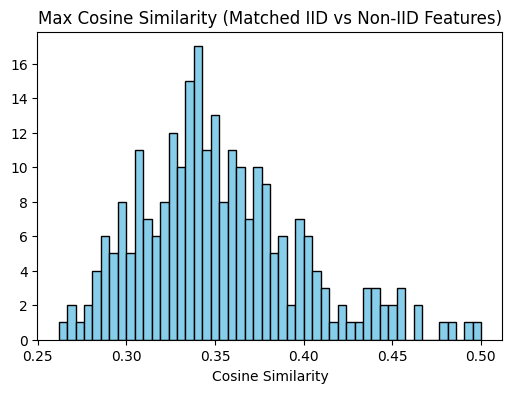


[3] Internal feature geometry
IID mean pairwise similarity: 0.0020990155
Non-IID mean pairwise similarity: 0.0013218301


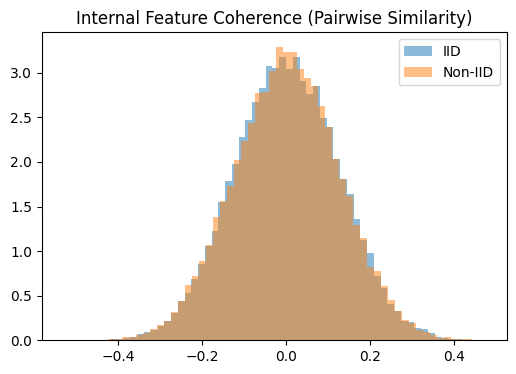


[4] PCA geometry


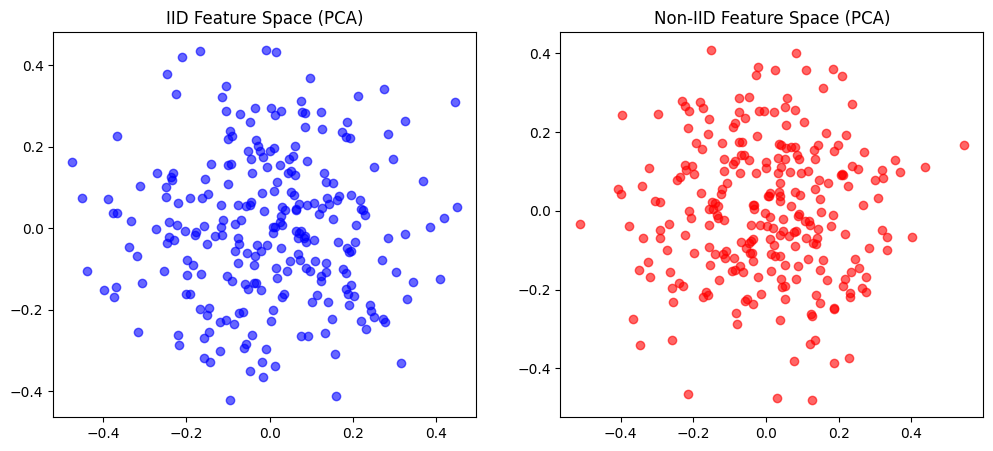


[5] Computing SAE feature activations
IID active feature fraction: 0.3234314024448395
Non-IID active feature fraction: 0.3317823112010956

[6] Feature entropy
IID Normalized Feature Entropy: 0.8403
Non-IID Normalized Feature Entropy: 0.8514
(High entropy = model uses features uniformly; Low = model relies on very few features)

[7] Per-Class Projection: Non-IID activations onto IID features
Class 0 | Mean Projection: 0.9073 | Strongest IID Feature: 86 (val: 7.3221)
Class 1 | Mean Projection: 0.4843 | Strongest IID Feature: 198 (val: 3.7998)
Class 2 | Mean Projection: 0.8225 | Strongest IID Feature: 86 (val: 6.4643)
Class 3 | Mean Projection: 0.8117 | Strongest IID Feature: 86 (val: 6.3363)
Class 4 | Mean Projection: 0.7071 | Strongest IID Feature: 86 (val: 5.6754)

[8] Feature similarity heatmaps


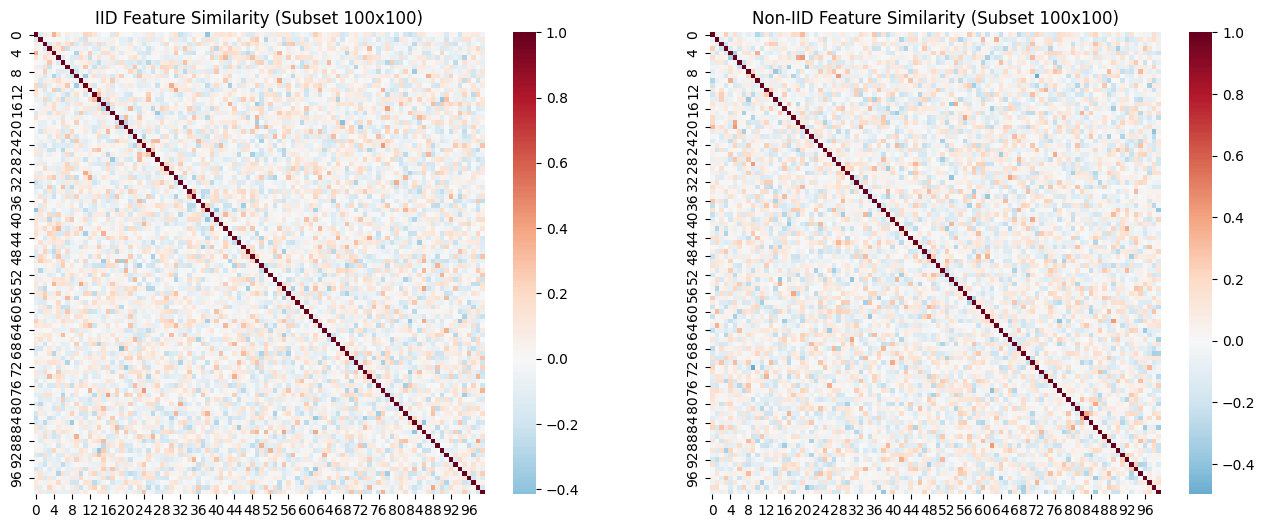


ANALYSIS COMPLETE


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0) 
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue
    
    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)
    
    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

In [11]:
from fedmi.env import show_images
show_images()

## Download Results

In [ ]:
import shutil
from IPython.display import FileLink

if os.path.isdir(CHECKPOINT_DIR):
    output_zip = "sae_experiment_results.zip"
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', CHECKPOINT_DIR)
    print(f"Results zipped to {output_zip}")
    display(FileLink(output_zip))
else:
    print("⚠ No results found in checkpoint directory.")